In [1]:
# ===============================================================
# 🧠 Step 1: Import Libraries
# ===============================================================
print("="*60)
print("🧠 STEP 1 START: Importing libraries...")
print("="*60)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tcn import TCN

print("✅ STEP 1 COMPLETE: Libraries imported")



🧠 STEP 1 START: Importing libraries...


I0000 00:00:1773049445.299933  565711 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773049445.332198  565711 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ STEP 1 COMPLETE: Libraries imported


I0000 00:00:1773049446.091860  565711 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df_hourly = pd.read_csv('cleandata.csv')
df_hourly.index = pd.to_datetime(df_hourly['timestamp'])
df_hourly.drop(columns=['timestamp'], inplace=True)

print("✅ STEP 2 COMPLETE: Hourly load")


✅ STEP 2 COMPLETE: Hourly load


In [3]:
df_hourly

,demand_kWh
timestamp,
2018-01-01 17:00:00,1.163317
2018-01-01 18:00:00,6.345366
2018-01-01 19:00:00,5.499317
2018-01-01 20:00:00,0.000000
2018-01-01 21:00:00,0.000000
...,...
2023-12-05 00:00:00,0.144595
2023-12-05 01:00:00,0.144595
2023-12-05 02:00:00,0.144595


In [4]:
# ===============================================================
# 🧠 Step 2: Prepare Datetime Index
# ===============================================================
print("="*60)
print("🧠 STEP 2 START: Preparing datetime index...")
print("="*60)

df_hourly.index = pd.to_datetime(df_hourly.index)
df_hourly = df_hourly.sort_index()
df_hourly.index.name = "Datetime"

# Keep only the target series
series = df_hourly["demand_kWh"].copy()

print("Series shape:", series.shape)
print("Date range  :", series.index.min(), "to", series.index.max())

print("✅ STEP 2 COMPLETE")

🧠 STEP 2 START: Preparing datetime index...
Series shape: (51924,)
Date range  : 2018-01-01 17:00:00 to 2023-12-05 04:00:00
✅ STEP 2 COMPLETE


In [5]:
df_hourly

,demand_kWh
Datetime,
2018-01-01 17:00:00,1.163317
2018-01-01 18:00:00,6.345366
2018-01-01 19:00:00,5.499317
2018-01-01 20:00:00,0.000000
2018-01-01 21:00:00,0.000000
...,...
2023-12-05 00:00:00,0.144595
2023-12-05 01:00:00,0.144595
2023-12-05 02:00:00,0.144595


In [8]:
# ===============================================================
# 🧠 Step 3: Split Data by Year
# ===============================================================
print("="*60)
print("🧠 STEP 3 START: Splitting train / val / test...")
print("="*60)

train = series.loc["2018-01-01":"2021-12-31 23:00:00"]
val   = series.loc["2021-01-01":"2021-12-31 23:00:00"]
test  = series.loc["2022-01-01":"2022-12-31 23:00:00"]

print("Train range:", train.index.min(), "to", train.index.max(), "| size:", len(train))
print("Val range  :", val.index.min(), "to", val.index.max(), "| size:", len(val))
print("Test range :", test.index.min(), "to", test.index.max(), "| size:", len(test))

print("✅ STEP 3 COMPLETE")

🧠 STEP 3 START: Splitting train / val / test...
Train range: 2018-01-01 17:00:00 to 2021-12-31 23:00:00 | size: 35047
Val range  : 2021-01-01 00:00:00 to 2021-12-31 23:00:00 | size: 8760
Test range : 2022-01-01 00:00:00 to 2022-12-31 23:00:00 | size: 8760
✅ STEP 3 COMPLETE


📊 STEP 4 START: Plotting split data...


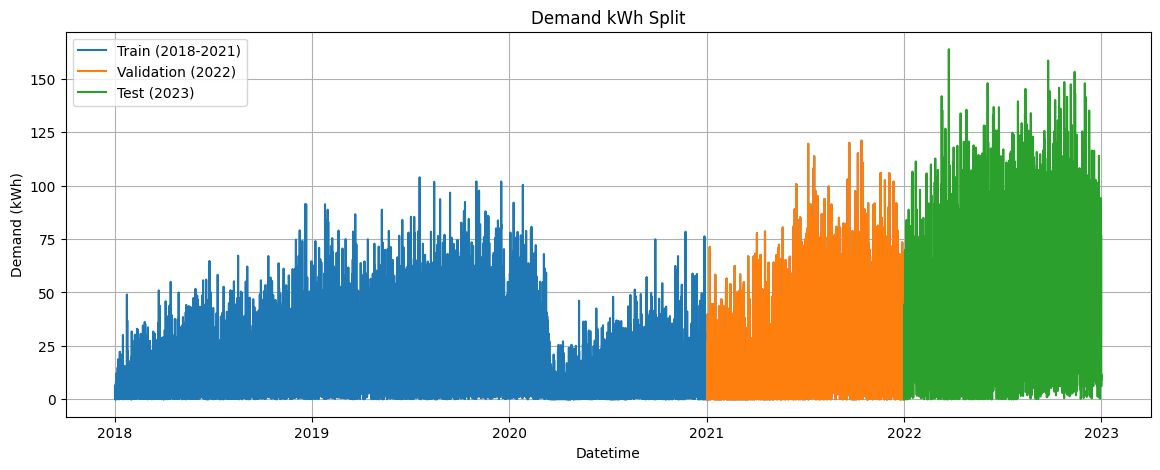

✅ STEP 4 COMPLETE


In [9]:
# ===============================================================
# 📊 Step 4: Plot the Split
# ===============================================================
print("="*60)
print("📊 STEP 4 START: Plotting split data...")
print("="*60)

plt.figure(figsize=(14,5))
plt.plot(train, label="Train (2018-2021)")
plt.plot(val, label="Validation (2022)")
plt.plot(test, label="Test (2023)")
plt.title("Demand kWh Split")
plt.xlabel("Datetime")
plt.ylabel("Demand (kWh)")
plt.legend()
plt.grid(True)
plt.show()

print("✅ STEP 4 COMPLETE")

In [12]:
# ===============================================================
# 🧠 Step 5: Fit Ordinary SARIMA on Training Set
# ===============================================================
print("="*60)
print("🧠 STEP 5 START: Fitting SARIMA on training set...")
print("="*60)

# Example SARIMA order
# order = (p, d, q)
# seasonal_order = (P, D, Q, s)
#
# For hourly demand, s=24 captures daily seasonality.
# You can tune these later.

order = (1,0,1)
seasonal_order = (1,0,1,24)

sarima_model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)

print(sarima_results.summary())

print("✅ STEP 5 COMPLETE")

🧠 STEP 5 START: Fitting SARIMA on training set...


/home/drix/miniconda3/envs/evcharging/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
/home/drix/miniconda3/envs/evcharging/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         demand_kWh   No. Observations:                35047
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -122924.556
Date:                            Mon, 09 Mar 2026   AIC                         245859.112
Time:                                    17:54:32   BIC                         245901.430
Sample:                                01-01-2018   HQIC                        245872.591
                                     - 12-31-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5415      0.005    119.721      0.000       0.533       0.550
ma.L1          0.2706      0.005   

In [17]:
test

Datetime
2022-01-01 00:00:00     0.000000
2022-01-01 01:00:00     0.000000
2022-01-01 02:00:00     0.000000
2022-01-01 03:00:00     0.000000
2022-01-01 04:00:00     0.000000
                         ...    
2022-12-31 19:00:00    15.610515
2022-12-31 20:00:00     6.063786
2022-12-31 21:00:00     9.526182
2022-12-31 22:00:00    11.666775
2022-12-31 23:00:00     9.169379
Name: demand_kWh, Length: 8760, dtype: float64

In [ ]:
# ===============================================================
# 🧠 Step 6: 7-Day Forecast
# ===============================================================
print("="*60)
print("🧠 STEP 6 START: Forecasting next 7 days...")
print("="*60)

forecast_horizon = 24 * 7  # 7 days ahead

forecast = sarima_results.forecast(steps=forecast_horizon)

# True values from test set
y_true = test.iloc[:forecast_horizon]

# Forecast values
y_pred = forecast

print("True shape:", y_true.shape)
print("Pred shape:", y_pred.shape)

print("✅ STEP 6 COMPLETE")

🧠 STEP 6 START: Forecasting next 7 days...
True shape: (168,)
Pred shape: (168,)
✅ STEP 6 COMPLETE


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("SARIMA Forecast Metrics (7 days)")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

SARIMA Forecast Metrics (7 days)
MAE  : 14.1473
RMSE : 19.6977
R2   : 0.4441


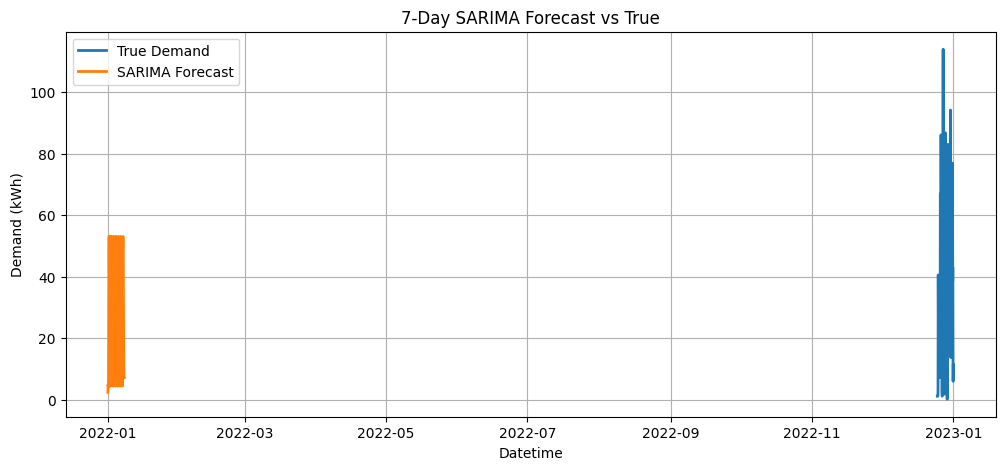

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_true.index, y_true.values, label="True Demand", linewidth=2)
plt.plot(y_pred.index, y_pred.values, label="SARIMA Forecast", linewidth=2)

plt.title("7-Day SARIMA Forecast vs True")
plt.xlabel("Datetime")
plt.ylabel("Demand (kWh)")
plt.legend()
plt.grid(True)

plt.show()

📊 STEP 10 START: Plotting first full-horizon forecast...


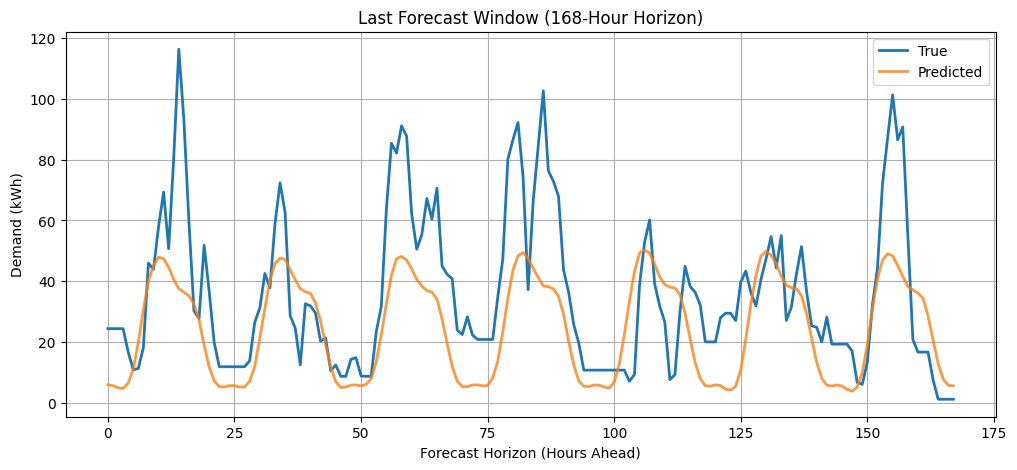

✅ STEP 10 COMPLETE


In [20]:
# ===============================================================
# 📊 Step 10: Plot First Forecast Window (Full Horizon)
# ===============================================================
print("="*60)
print("📊 STEP 10 START: Plotting first full-horizon forecast...")
print("="*60)

import matplotlib.pyplot as plt
import numpy as np

# first prediction window
y_true_h = y_true[-HORIZON]
y_pred_h = y_pred[-HORIZON]

horizon = len(y_true_h)
t = np.arange(horizon)

plt.figure(figsize=(12,5))

plt.plot(t, y_true_h, label="True", linewidth=2)
plt.plot(t, y_pred_h, label="Predicted", linewidth=2, alpha=0.8)

plt.title("Last Forecast Window (168-Hour Horizon)")
plt.xlabel("Forecast Horizon (Hours Ahead)")
plt.ylabel("Demand (kWh)")
plt.legend()
plt.grid(True)

plt.show()

print("✅ STEP 10 COMPLETE")

In [21]:
# ===============================================================
# 🧠 Step 11: Save Model (For Thesis Reproducibility)
# ======================================a=========================
#FIX 1 (RECOMMENDED): Use the native Keras format
print("="*60)
print("🧠 STEP 11 START: Saving model (Keras format)...")
print("="*60)

model.save("TCN_only_model.keras")

print("✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY")
print("="*60)


🧠 STEP 11 START: Saving model (Keras format)...


✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY


In [22]:
#FIX 2 (ALSO VALID): Save weights only (most robust)

print("="*60)
print("🧠 STEP 11 START: Saving model weights only...")
print("="*60)

model.save_weights("TCN_only_weights.weights.h5")

print("✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY")
print("="*60)


🧠 STEP 11 START: Saving model weights only...
✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY
